In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
sns.set_style("whitegrid")

print("All libraries loaded.")

All libraries loaded.


In [2]:
from src.data.loader import BookCrossingLoader
from src.data.preprocessor import BookCrossingPreprocessor

loader = BookCrossingLoader("../data/raw")
raw = loader.load_all(verbose=False)

prep = BookCrossingPreprocessor()
clean = prep.fit_transform(raw)

users   = clean.users
books   = clean.books
ratings = clean.ratings

sparse_matrix = prep.build_sparse_matrix(clean)
print(f"Sparse matrix shape: {sparse_matrix.shape}")

Sparse matrix shape: (105283, 340054)


In [3]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# Reduce 340K book dimensions down to 50 latent components
# Same approach used in Task 3 age estimation
svd = TruncatedSVD(n_components=50, random_state=42)
X = svd.fit_transform(sparse_matrix)

# Normalize for better clustering performance
X = Normalizer().fit_transform(X)

print(f"Reduced matrix shape: {X.shape}")
print(f"Explained variance (50 components): {svd.explained_variance_ratio_.sum():.4%}")

Reduced matrix shape: (105283, 50)
Explained variance (50 components): 11.8487%


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 4, 6, 8, 10, 20, 30]
kmeans_results = {}
inertias       = []
silhouette_scores = []

print("Running KMeans for multiple k values...")
for k in tqdm(k_values, desc="KMeans"):
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X)
    inertia = km.inertia_

    # Silhouette score is expensive for large datasets — sample 5000 users
    sample_idx = np.random.choice(len(X), size=min(5000, len(X)), replace=False)
    sil = silhouette_score(X[sample_idx], labels[sample_idx])

    kmeans_results[k] = {
        'model':     km,
        'labels':    labels,
        'inertia':   inertia,
        'silhouette': sil
    }
    inertias.append(inertia)
    silhouette_scores.append(sil)

    print(f"  k={k:>2} | Inertia: {inertia:>12,.2f} | Silhouette: {sil:.4f}")

print("\nKMeans complete.")

Running KMeans for multiple k values...


KMeans:  14%|████████████▋                                                                            | 1/7 [00:06<00:36,  6.14s/it]

  k= 2 | Inertia:    67,180.42 | Silhouette: 0.1825


KMeans:  29%|█████████████████████████▍                                                               | 2/7 [00:10<00:25,  5.10s/it]

  k= 4 | Inertia:    61,476.77 | Silhouette: 0.1946


...

  k=10 | Inertia:    54,972.10 | Silhouette: 0.2366


KMeans:  86%|████████████████████████████████████████████████████████████████████████████▎            | 6/7 [00:42<00:08,  8.34s/it]

  k=20 | Inertia:    48,647.90 | Silhouette: 0.2534


KMeans: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:00<00:00,  8.67s/it]

  k=30 | Inertia:    43,477.96 | Silhouette: 0.2913

KMeans complete.


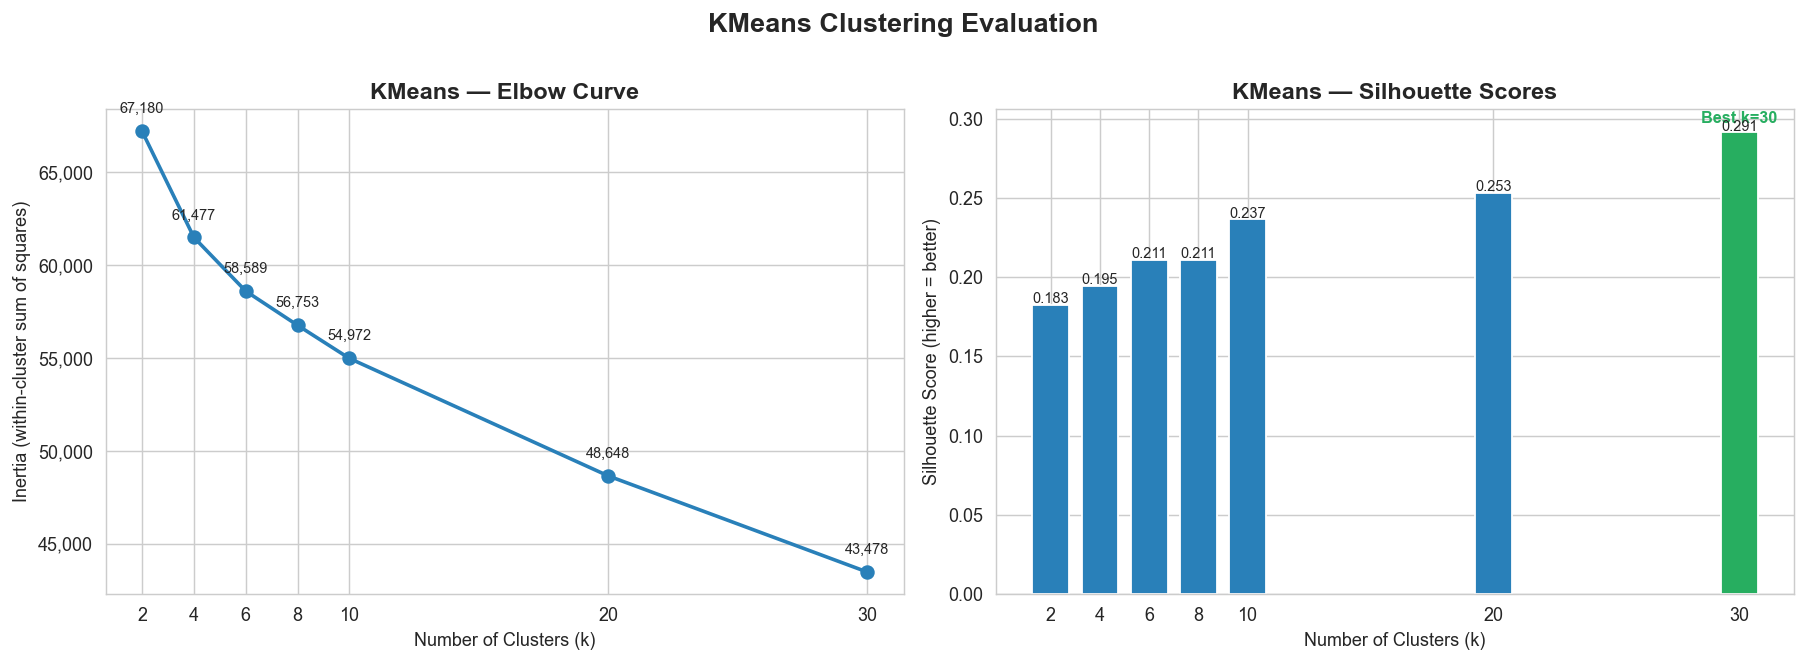

Best k by silhouette score: k=30 (score=0.2913)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Elbow curve
axes[0].plot(k_values, inertias, 'o-', color='#2980b9', linewidth=2, markersize=7)
axes[0].set_title('KMeans — Elbow Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].set_xticks(k_values)
for k, inertia in zip(k_values, inertias):
    axes[0].annotate(f'{inertia:,.0f}', (k, inertia),
                     textcoords="offset points", xytext=(0, 10),
                     fontsize=8, ha='center')

# Right: Silhouette scores
colors = ['#27ae60' if s == max(silhouette_scores) else '#2980b9' for s in silhouette_scores]
axes[1].bar(k_values, silhouette_scores, color=colors, edgecolor='white', width=1.5)
axes[1].set_title('KMeans — Silhouette Scores', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_xticks(k_values)
best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
axes[1].annotate(f'Best k={best_k}', (best_k, max(silhouette_scores)),
                 textcoords="offset points", xytext=(0, 5),
                 fontsize=9, ha='center', color='#27ae60', fontweight='bold')
for k, s in zip(k_values, silhouette_scores):
    axes[1].text(k, s + 0.001, f'{s:.3f}', ha='center', fontsize=8)

plt.suptitle('KMeans Clustering Evaluation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/kmeans_evaluation.png', bbox_inches='tight')
plt.show()

print(f"Best k by silhouette score: k={best_k} (score={max(silhouette_scores):.4f})")

In [6]:
from sklearn.cluster import AgglomerativeClustering

# Hierarchical clustering is memory-intensive on full dataset
# Use a representative sample of 10,000 users
SAMPLE_SIZE = 10000
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=SAMPLE_SIZE, replace=False)
X_sample   = X[sample_idx]

hierarchical_results = {}
hier_silhouette_scores = []

print(f"Running Hierarchical Clustering on {SAMPLE_SIZE:,} user sample...")
for k in tqdm(k_values, desc="Hierarchical"):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels)

    hierarchical_results[k] = {
        'labels':     labels,
        'silhouette': sil
    }
    hier_silhouette_scores.append(sil)
    print(f"  k={k:>2} | Silhouette: {sil:.4f}")

print("\nHierarchical clustering complete.")

Running Hierarchical Clustering on 10,000 user sample...


Hierarchical:  14%|███████████▊                                                                       | 1/7 [00:15<01:31, 15.32s/it]

  k= 2 | Silhouette: 0.1849


Hierarchical:  29%|███████████████████████▋                                                           | 2/7 [00:30<01:16, 15.31s/it]

  k= 4 | Silhouette: 0.1765


...

  k=10 | Silhouette: 0.2092


Hierarchical:  86%|███████████████████████████████████████████████████████████████████████▏           | 6/7 [01:29<00:14, 14.83s/it]

  k=20 | Silhouette: 0.2449


Hierarchical: 100%|███████████████████████████████████████████████████████████████████████████████████| 7/7 [01:43<00:00, 14.77s/it]

  k=30 | Silhouette: 0.2705

Hierarchical clustering complete.


In [7]:
from sklearn.cluster import DBSCAN

# DBSCAN on sample — tune eps and min_samples
print("Running DBSCAN...")
dbscan_configs = [
    {'eps': 0.3, 'min_samples': 5},
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 0.5, 'min_samples': 10},
]

dbscan_results = []
for cfg in dbscan_configs:
    db = DBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'], n_jobs=-1)
    labels = db.fit_predict(X_sample)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    
    if n_clusters > 1:
        sil = silhouette_score(X_sample[labels != -1], labels[labels != -1])
    else:
        sil = -1

    dbscan_results.append({
        'eps':        cfg['eps'],
        'min_samples': cfg['min_samples'],
        'n_clusters': n_clusters,
        'n_noise':    n_noise,
        'silhouette': sil,
        'labels':     labels
    })
    print(f"  eps={cfg['eps']} min_samples={cfg['min_samples']} → "
          f"{n_clusters} clusters, {n_noise} noise points, silhouette={sil:.4f}")

# Pick best DBSCAN config (most clusters with positive silhouette)
best_dbscan = max(
    [r for r in dbscan_results if r['silhouette'] > 0],
    key=lambda x: x['silhouette'],
    default=dbscan_results[0]
)
print(f"\nBest DBSCAN config: eps={best_dbscan['eps']}, "
      f"min_samples={best_dbscan['min_samples']}, "
      f"clusters={best_dbscan['n_clusters']}")

Running DBSCAN...
  eps=0.3 min_samples=5 → 99 clusters, 5611 noise points, silhouette=0.9258
  eps=0.5 min_samples=5 → 150 clusters, 4304 noise points, silhouette=0.7621
  eps=0.5 min_samples=10 → 64 clusters, 5023 noise points, silhouette=0.8205

Best DBSCAN config: eps=0.3, min_samples=5, clusters=99


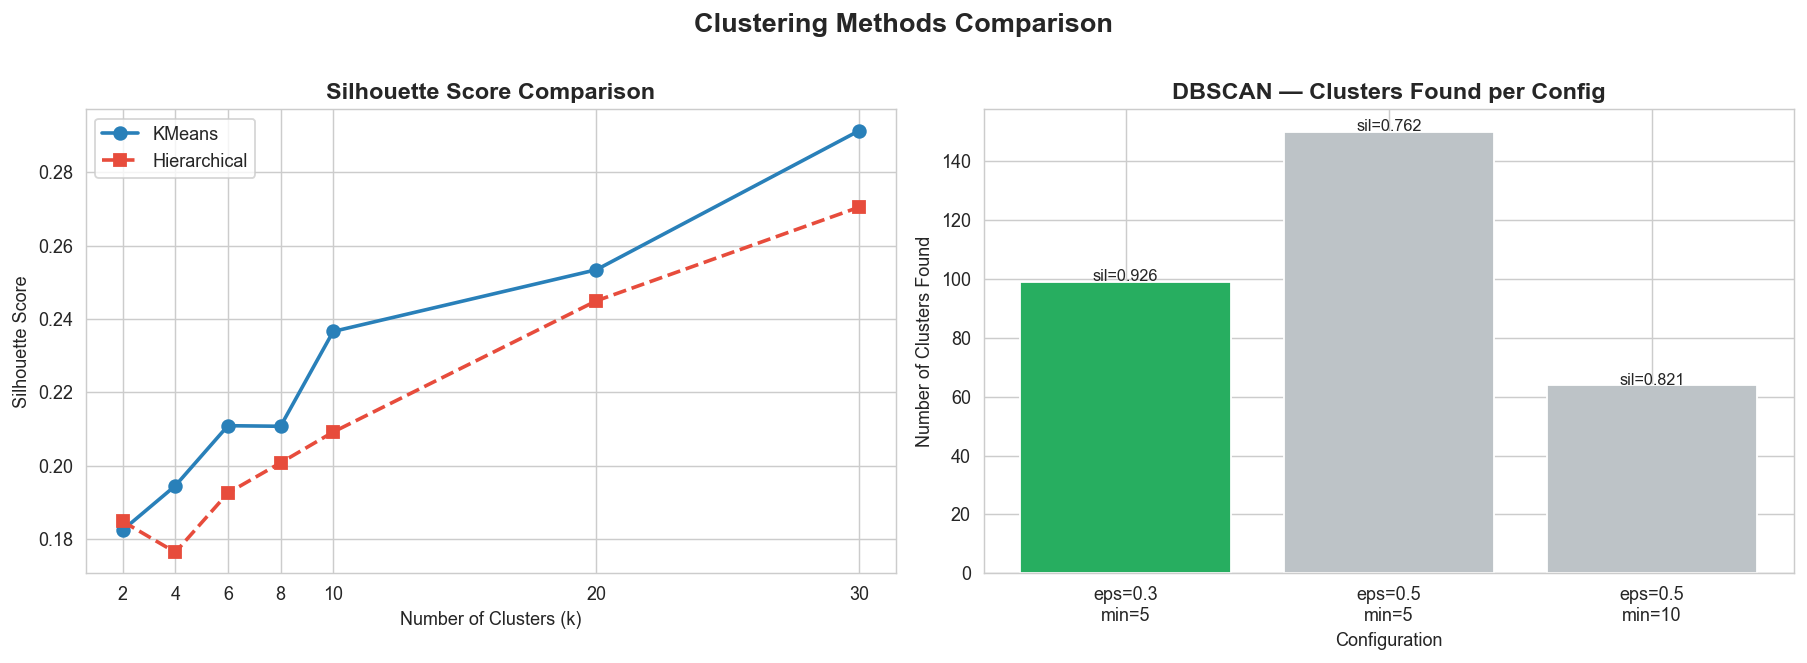

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: KMeans vs Hierarchical silhouette comparison
axes[0].plot(k_values, silhouette_scores, 'o-', color='#2980b9',
             linewidth=2, markersize=7, label='KMeans')
axes[0].plot(k_values, hier_silhouette_scores, 's--', color='#e74c3c',
             linewidth=2, markersize=7, label='Hierarchical')
axes[0].set_title('Silhouette Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(k_values)
axes[0].legend()

# Right: DBSCAN results summary
dbscan_df = pd.DataFrame(dbscan_results)
dbscan_df['config'] = dbscan_df.apply(
    lambda r: f"eps={r['eps']}\nmin={r['min_samples']}", axis=1)
axes[1].bar(dbscan_df['config'], dbscan_df['n_clusters'],
            color=['#27ae60' if r['silhouette'] == dbscan_df['silhouette'].max()
                   else '#bdc3c7' for _, r in dbscan_df.iterrows()])
axes[1].set_title('DBSCAN — Clusters Found per Config', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Number of Clusters Found')
for i, (_, row) in enumerate(dbscan_df.iterrows()):
    axes[1].text(i, row['n_clusters'] + 0.1,
                 f"sil={row['silhouette']:.3f}", ha='center', fontsize=9)

plt.suptitle('Clustering Methods Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/clustering_comparison.png', bbox_inches='tight')
plt.show()

In [9]:
# Use k=10 as specified in the assignment
k = 10
labels_k10 = kmeans_results[k]['labels']

# Map user indices back to user_ids
user_ids_in_order = [clean.idx_to_user[i] for i in range(len(labels_k10))]
user_cluster_df = pd.DataFrame({
    'user_id':   user_ids_in_order,
    'cluster':   labels_k10
})

# Join with ratings to get books per cluster
ratings_with_cluster = ratings.merge(user_cluster_df, on='user_id', how='inner')
ratings_with_cluster = ratings_with_cluster[ratings_with_cluster['rating'] > 0]

# Top 10 books per cluster
cluster_profiles = {}
output_lines = []

for cluster_id in range(k):
    cluster_ratings = ratings_with_cluster[
        ratings_with_cluster['cluster'] == cluster_id
    ]
    top_books = (
        cluster_ratings
        .groupby('isbn')
        .size()
        .reset_index(name='frequency')
        .merge(books[['isbn', 'title']], on='isbn', how='left')
        .dropna(subset=['title'])
        .sort_values('frequency', ascending=False)
        .head(10)
    )
    cluster_profiles[cluster_id] = top_books

    output_lines.append(f"KMeans, Cluster {cluster_id}")
    for _, row in top_books.iterrows():
        output_lines.append(f"{row['title']}, {row['frequency']}")
    output_lines.append("")

    n_users = (labels_k10 == cluster_id).sum()
    print(f"Cluster {cluster_id:>2} ({n_users:>6,} users) — "
          f"Top book: {top_books.iloc[0]['title'][:50] if len(top_books) > 0 else 'N/A'}")

# Save to text file
with open('../outputs/clustering_results.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(output_lines))

print("\nSaved to outputs/clustering_results.txt")

Cluster  0 (44,882 users) — Top book: The Lovely Bones: A Novel
Cluster  1 ( 2,007 users) — Top book: The Da Vinci Code
Cluster  2 ( 9,313 users) — Top book: The Catcher in the Rye
Cluster  3 ( 7,482 users) — Top book: A Painted House
Cluster  4 ( 8,337 users) — Top book: The Red Tent (Bestselling Backlist)
Cluster  5 ( 6,128 users) — Top book: Harry Potter and the Sorcerer's Stone (Harry Potte
Cluster  6 ( 6,129 users) — Top book: Free
Cluster  7 ( 3,238 users) — Top book: The Nanny Diaries: A Novel
Cluster  8 ( 6,202 users) — Top book: Wild Animus
Cluster  9 (11,565 users) — Top book: Divine Secrets of the Ya-Ya Sisterhood: A Novel

Saved to outputs/clustering_results.txt


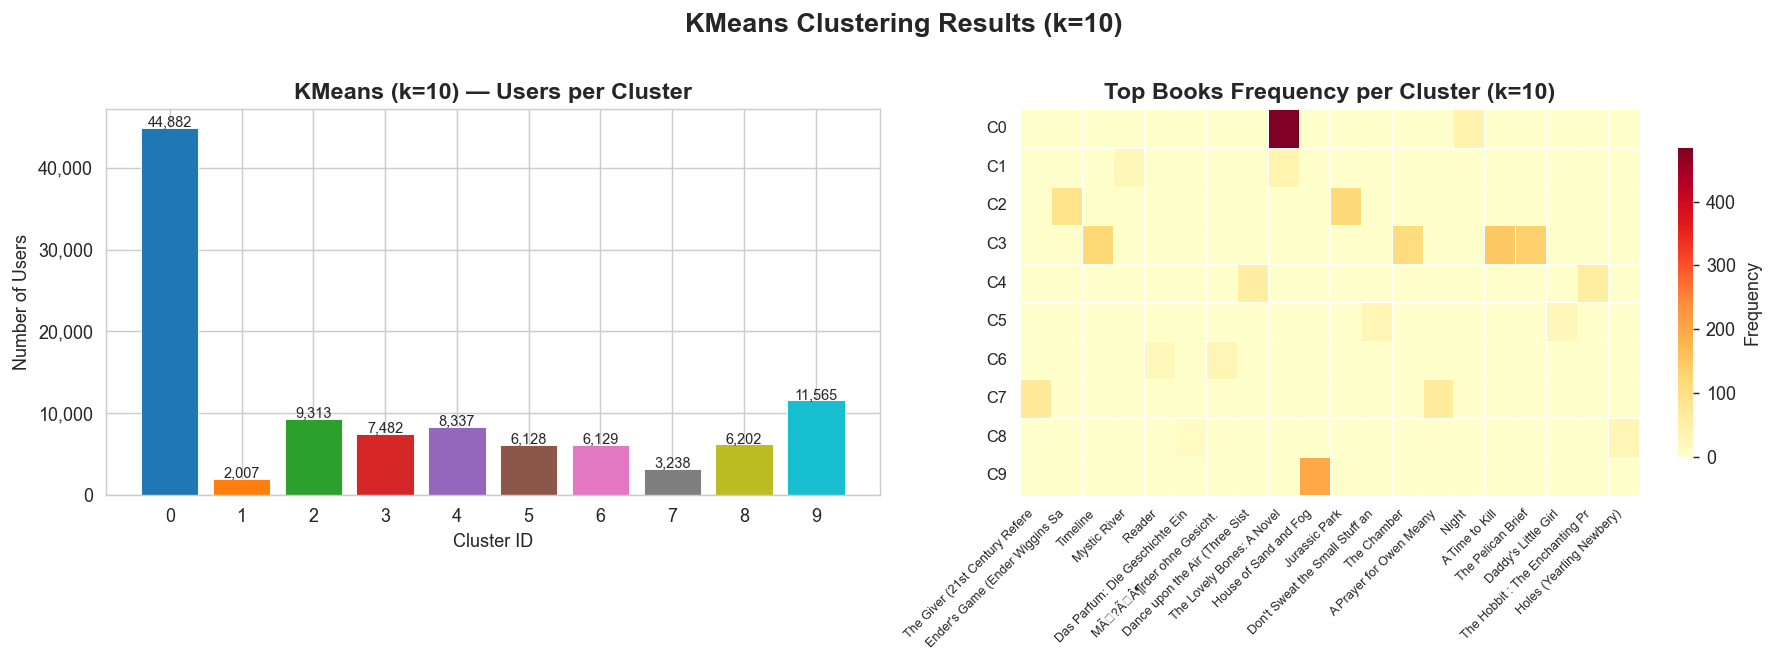

In [10]:
cluster_sizes = pd.Series(labels_k10).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of cluster sizes
axes[0].bar(cluster_sizes.index, cluster_sizes.values,
            color=plt.cm.tab10(np.linspace(0, 1, k)),
            edgecolor='white', linewidth=0.5)
axes[0].set_title('KMeans (k=10) — Users per Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_xticks(range(k))
for i, v in enumerate(cluster_sizes.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=8)

# Right: top book heatmap across clusters
heatmap_data = []
all_top_books = set()
for cid, profile in cluster_profiles.items():
    all_top_books.update(profile['title'].tolist())

all_top_books = list(all_top_books)[:20]
for cid in range(k):
    profile = cluster_profiles[cid].set_index('title')['frequency'].to_dict()
    row = [profile.get(book, 0) for book in all_top_books]
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data,
                           index=[f'C{i}' for i in range(k)],
                           columns=[b[:30] for b in all_top_books])

sns.heatmap(heatmap_df, ax=axes[1], cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Frequency', 'shrink': 0.8},
            xticklabels=True, yticklabels=True)
axes[1].set_title('Top Books Frequency per Cluster (k=10)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=7)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('KMeans Clustering Results (k=10)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/cluster_profiles.png', bbox_inches='tight')
plt.show()

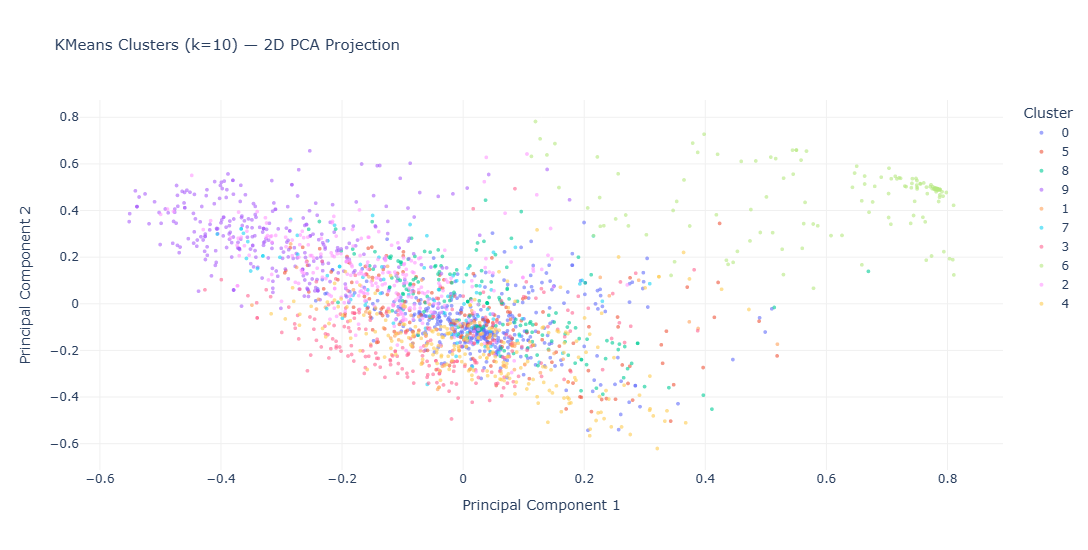

In [12]:
# 2D PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

# Sample 3000 points for the scatter plot
sample_n = 3000
sample_idx = np.random.choice(len(X_2d), size=sample_n, replace=False)

plot_df = pd.DataFrame({
    'PC1':     X_2d[sample_idx, 0],
    'PC2':     X_2d[sample_idx, 1],
    'Cluster': [str(labels_k10[i]) for i in sample_idx]
})

fig = px.scatter(
    plot_df, x='PC1', y='PC2', color='Cluster',
    title='KMeans Clusters (k=10) — 2D PCA Projection',
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
    color_discrete_sequence=px.colors.qualitative.Plotly,
    opacity=0.6,
    width=850, height=550
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(
    title_font_size=15,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    legend_title_text='Cluster'
)
fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0', zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0', zeroline=False)
fig.show()

In [13]:
print("=" * 55)
print("  Module 3 Complete — User Group Discovery")
print("=" * 55)
print()
print(f"  KMeans:       {len(k_values)} models (k = {k_values})")
print(f"  Hierarchical: {len(k_values)} models (k = {k_values})")
print(f"  DBSCAN:       {len(dbscan_results)} configurations")
print()
print(f"  Best k (KMeans silhouette):       k={best_k}")
print(f"  Best k (Hierarchical silhouette): k={k_values[hier_silhouette_scores.index(max(hier_silhouette_scores))]}")
print(f"  Best DBSCAN: eps={best_dbscan['eps']}, min_samples={best_dbscan['min_samples']}")
print()
print("  Output files:")
print("    outputs/clustering_results.txt")
print()
print("  Charts saved:")
import os
charts = ['kmeans_evaluation.png', 'clustering_comparison.png',
          'cluster_profiles.png']
for c in charts:
    path = f'../assets/{c}'
    if os.path.exists(path):
        print(f"    assets/{c}  ({os.path.getsize(path)/1024:.1f} KB)")

  Module 3 Complete — User Group Discovery

  KMeans:       7 models (k = [2, 4, 6, 8, 10, 20, 30])
  Hierarchical: 7 models (k = [2, 4, 6, 8, 10, 20, 30])
  DBSCAN:       3 configurations

  Best k (KMeans silhouette):       k=30
  Best k (Hierarchical silhouette): k=30
  Best DBSCAN: eps=0.3, min_samples=5

  Output files:
    outputs/clustering_results.txt

  Charts saved:
    assets/kmeans_evaluation.png  (78.1 KB)
    assets/clustering_comparison.png  (82.4 KB)
    assets/cluster_profiles.png  (104.6 KB)
